
Alice sent 00


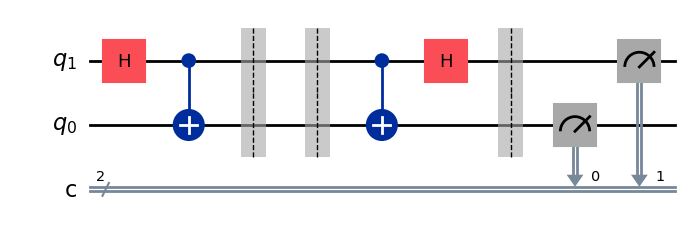

{'00': 10000}

Alice sent 01


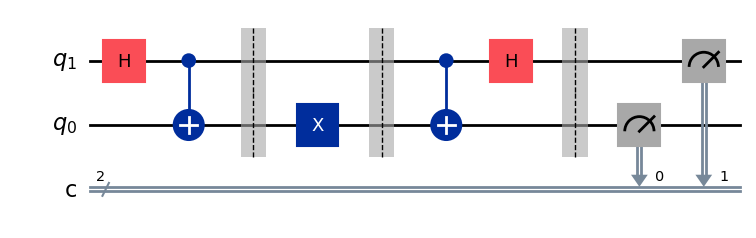

{'01': 10000}

Alice sent 10


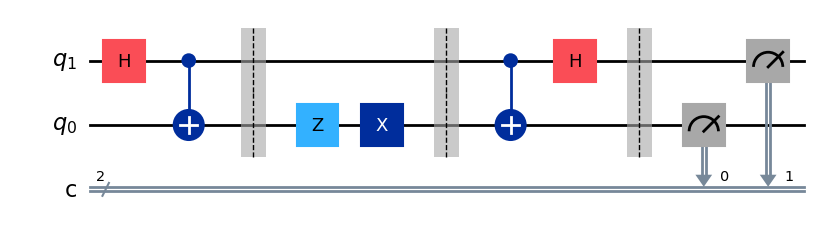

{'11': 10000}

Alice sent 11


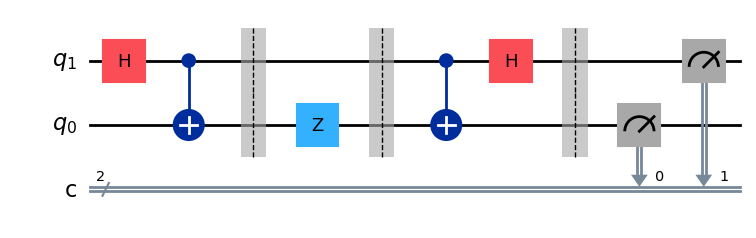

{'10': 10000}


In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np
from math import pi
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import SGate, XGate, UnitaryGate, IGate
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import UnitaryGate


# --- Matrix ---
c1 = np.pi/2
c2 = np.pi/4

theta1 = (c1 - c2)
theta2 = (c1 + c2)

U = np.array([
    [np.cos(theta1), 0, 0, -1j*np.sin(theta1)],
    [0, np.cos(theta2), -1j*np.sin(theta2), 0],
    [0, -1j*np.sin(theta2), np.cos(theta2), 0],
    [-1j*np.sin(theta1), 0, 0, np.cos(theta1)]
])

B = Operator(U)

def b_tilde(B_op: Operator):
    S = SGate().to_matrix()
    #I = IGate().to_matrix()
    X = XGate().to_matrix()

    return UnitaryGate(np.kron(S, X) @ B_op.data @ np.kron(S, X), label="B_tilde")

u_final = b_tilde(B)

u_final_dg = u_final.adjoint()

all_pairs = ['00','01','10','11']
backend = AerSimulator()
counts_dict = {}

for idx, pair in enumerate(all_pairs):
    qc = QuantumCircuit(2, 2)

    # --- Entanglement creation (UNCHANGED) ---
    qc.h(1)
    qc.cx(1, 0)
    qc.barrier()

    # --- Alice encoding ---

    if pair == '00':
        pass
    elif pair == '01':
        qc.x(0)
    elif pair == '10':
        qc.z(0)
        qc.x(0)
    elif pair == '11':
        qc.z(0)

    qc.barrier()

    # --- Bob decoding using B-tilde dagger ---
    qc.cx(1,0)
    qc.h(1)
    qc.barrier()

    # --- Measurement ---
    qc.measure(0, 0)
    qc.measure(1, 1)

    result = backend.run(qc, shots=10000).result()
    counts = result.get_counts()

    counts_dict[pair] = counts

    print(f"\nAlice sent {pair}")

    display(qc.draw(output='mpl', reverse_bits=True))
    print(counts)

    fig = plot_histogram(counts, title=f"SDCoding - Alice sent {pair}")
    plt.show()